# Quiz Performance Analysis: Identifying Discouragement

This notebook presents a comprehensive analysis to evaluate the hypothesis,
> *"Students who fail the first question (Q1) are statistically more likely to have a lower success rate on subsequent questions (Q2-Q5) compared to those who get Q1 correct."*

The dataset contains information about the quiz attempts by students, including start time, completion time, total marks, and marks for each question. Because students can attempt a quiz multiple times, this analysis keeps only each student's first attempt to reduce learning-effect bias. The analysis focuses on preprocessing the data and visualizing question-wise performance to identify difficulty patterns.

## 1. Import Libraries
First step is to load the required Python libraries required for the analysis.
- `NumPy` - for numerical operations
- `Pandas` - for data loading and pre-processing 
- `Matplotlib` - for data visualization

In [29]:
# Import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load and Inspect the Dataset
The next step is to load the three quiz CSV files into _pandas_ `DataFrame` and inspect their structure before preprocessing.

In [30]:
# Load the datasets
quiz1_data = pd.read_csv("../dataset/marks/quiz1/quiz1_marks.csv")
quiz2_data = pd.read_csv("../dataset/marks/quiz2/quiz2_marks.csv") 
quiz3_data = pd.read_csv("../dataset/marks/quiz3/quiz3_marks.csv")

First few rows of one dataset and summary of the data is printed to gain a clear idea about the formatting and content of the dataset.

In [31]:
# Inspect first few rows
quiz2_data.head()

,Student Code,State,Started on,Completed,Time taken,Grade/10.00,Q. 1 /2.00,Q. 2 /2.00,Q. 3 /2.00,Q. 4 /2.00,Q. 5 /2.00
0,5,Finished,14 March 2022 12:20 PM,17 March 2022 9:53 AM,2 days 21 hours,4.00,0.00,0.00,2.00,0.00,2.00
1,1,Finished,14 March 2022 2:56 PM,14 March 2022 3:01 PM,4 mins 55 secs,6.00,0.00,2.00,2.00,2.00,0.00
2,3,Finished,14 March 2022 6:48 PM,14 March 2022 7:13 PM,24 mins 55 secs,0.00,0.00,0.00,0.00,0.00,0.00
3,2,Finished,14 March 2022 7:22 PM,14 March 2022 7:57 PM,34 mins 51 secs,6.00,2.00,0.00,2.00,0.00,2.00
4,2,In progress,14 March 2022 7:58 PM,-,-,-,-,-,-,-,-


In [32]:
# Information about the dataset
quiz1_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13989 entries, 0 to 13988
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Student Code  13989 non-null  int64
 1   State         13989 non-null  str  
 2   Started on    13989 non-null  str  
 3   Completed     13989 non-null  str  
 4   Time taken    13989 non-null  str  
 5   Grade/10.00   13989 non-null  str  
 6   Q. 1 /2.00    13989 non-null  str  
 7   Q. 2 /2.00    13989 non-null  str  
 8   Q. 3 /2.00    13989 non-null  str  
 9   Q. 4 /2.00    13989 non-null  str  
 10  Q. 5 /2.00    13989 non-null  str  
dtypes: int64(1), str(10)
memory usage: 1.2 MB


According to the above information, it is evident that several columns need data type conversions. Marks should be numeric, date fields should be converted into `datetime`. Plus, `Time taken` can be converted into seconds. Before doing the type conversions, a proper understanding of the possible values in each column is required. `Student Code`, `Started on`, `Completed`, and `Time taken` columns are ignored here because those are not categorical variables. Marks can also be non-categorical variable, however, since the range is small, having a look is a better idea.

In [33]:
# Inspect values in each column
columns = ["State", "Grade/10.00", "Q. 1 /2.00", "Q. 2 /2.00", "Q. 3 /2.00", "Q. 4 /2.00", "Q. 5 /2.00"]
for column in columns:
    print(f"Unique Values in the column: '{column}'")
    print("-" * 40)
    q1_vals = {k: int(v) for k, v in quiz1_data[column].value_counts().to_dict().items()}
    print(f"Quiz 1: {q1_vals}")
    q2_vals = {k: int(v) for k, v in quiz2_data[column].value_counts().to_dict().items()}
    print(f"Quiz 2: {q2_vals}")
    q3_vals = {k: int(v) for k, v in quiz3_data[column].value_counts().to_dict().items()}
    print(f"Quiz 3: {q3_vals}")
    print()

Unique Values in the column: 'State'
----------------------------------------
Quiz 1: {'Finished': 13911, 'In progress': 78}
Quiz 2: {'Finished': 10430, 'In progress': 44}
Quiz 3: {'Finished': 8066, 'In progress': 67}

Unique Values in the column: 'Grade/10.00'
----------------------------------------
Quiz 1: {'4.00': 4136, '2.00': 3580, '6.00': 2230, '0.00': 2139, '8.00': 1303, '10.00': 523, '-': 78}
Quiz 2: {'4.00': 3078, '6.00': 2279, '2.00': 1980, '8.00': 1447, '0.00': 830, '10.00': 816, '-': 44}
Quiz 3: {'6.00': 2717, '8.00': 2009, '4.00': 1430, '10.00': 1105, '2.00': 682, '0.00': 123, '-': 67}

Unique Values in the column: 'Q. 1 /2.00'
----------------------------------------
Quiz 1: {'0.00': 9186, '2.00': 4708, '-': 95}
Quiz 2: {'0.00': 5521, '2.00': 4880, '-': 73}
Quiz 3: {'2.00': 6028, '0.00': 2019, '-': 86}

Unique Values in the column: 'Q. 2 /2.00'
----------------------------------------
Quiz 1: {'2.00': 8827, '0.00': 5066, '-': 96}
Quiz 2: {'0.00': 5435, '2.00': 4983, '-':

Inspection shows that marks per question are mostly `2`, `0`, or `-`. Here, `2` indicates a correct answer, `0` indicates an incorrect answer, and `-` is treated as missing. Rows with `State = In progress` are incomplete attempts and are removed before analysis.

## 3. Data Pre-processing
The datasets are cleaned and standardized before analysis. The key steps are:

- Convert marks columns to numeric values (`errors='coerce'`) so `-` values become missing (`NaN`).
- Convert `Started on` and `Completed` to datetime values.
- Convert `Time taken` into seconds for consistent numeric handling.
- Remove incomplete attempts (`State = In progress`).
- Keep only each student's first attempt to reduce learning-effect bias.

In [34]:
# Convert marks columns to numeric, coercing errors to NaN
marks_columns = ["Grade/10.00", "Q. 1 /2.00", "Q. 2 /2.00", "Q. 3 /2.00", "Q. 4 /2.00", "Q. 5 /2.00"]

for column in marks_columns:
    quiz1_data[column] = pd.to_numeric(quiz1_data[column], errors='coerce')
    quiz1_data[column] = quiz1_data[column].astype('Int64')

    quiz2_data[column] = pd.to_numeric(quiz2_data[column], errors='coerce')
    quiz2_data[column] = quiz2_data[column].astype('Int64')

    quiz3_data[column] = pd.to_numeric(quiz3_data[column], errors='coerce')
    quiz3_data[column] = quiz3_data[column].astype('Int64')

In [35]:
# Convert date-time columns to datetime, coercing errors to NaT
datetime_columns = ["Started on", "Completed"]

for column in datetime_columns:
    quiz1_data[column] = pd.to_datetime(quiz1_data[column], errors='coerce', format='mixed')
    quiz2_data[column] = pd.to_datetime(quiz2_data[column], errors='coerce', format='mixed')
    quiz3_data[column] = pd.to_datetime(quiz3_data[column], errors='coerce', format='mixed')

In [36]:
def convert_time_to_seconds(time_str: str):
    """Convert a time string in the format 'DD days HH hours MM mins SS secs' to total seconds."""
    if pd.isna(time_str) or not isinstance(time_str, str):
        return np.nan
    try:
        # Split the string and extract days, hours, minutes, and seconds
        parts = time_str.strip().split()
        d, h, m, s = 0, 0, 0, 0
        for i in range(0, len(parts), 2):
            unit = parts[i+1]
            value = int(parts[i])
            if unit in ('days', 'day'):
                d = value
            elif unit in ('hours', 'hour'):
                h = value
            elif unit in ('mins', 'min'):
                m = value
            elif unit in ('secs', 'sec'):
                s = value
            else:
                # Years are returned as NaN. Quiz attempts with years duration are likely outliers.
                return np.nan
        return int(d * 86400 + h * 3600 + m * 60 + s)
    except (ValueError, IndexError):
        return np.nan

In [37]:
# Convert "Time taken" to total seconds
quiz1_data["Time taken (seconds)"] = quiz1_data["Time taken"].apply(convert_time_to_seconds)
quiz1_data.drop(columns=["Time taken"], inplace=True)

quiz2_data["Time taken (seconds)"] = quiz2_data["Time taken"].apply(convert_time_to_seconds)
quiz2_data.drop(columns=["Time taken"], inplace=True)

quiz3_data["Time taken (seconds)"] = quiz3_data["Time taken"].apply(convert_time_to_seconds)
quiz3_data.drop(columns=["Time taken"], inplace=True)

In [38]:
# Drop the "In Progess" State
quiz1_data = quiz1_data[quiz1_data['State'] != 'In progress']
quiz2_data = quiz2_data[quiz2_data['State'] != 'In progress']
quiz3_data = quiz3_data[quiz3_data['State'] != 'In progress']

# Drop rrows with the missing values in 'Time taken (seconds)' column
quiz1_data = quiz1_data.dropna(subset=['Time taken (seconds)'])
quiz2_data = quiz2_data.dropna(subset=['Time taken (seconds)'])
quiz3_data = quiz3_data.dropna(subset=['Time taken (seconds)'])

**Important**: Students can attempt each quiz multiple times. Later attempts may reflect prior exposure rather than true first-try understanding. To keep the comparison fair, this notebook keeps only the first attempt per student when evaluating the hypothesis.

In [39]:
# Keep only the first attempt per student based on earliest start/completion time
quiz1_data = quiz1_data.sort_values(['Student Code', 'Started on', 'Completed']).groupby('Student Code', sort=False).head(1).reset_index(drop=True)
quiz2_data = quiz2_data.sort_values(['Student Code', 'Started on', 'Completed']).groupby('Student Code', sort=False).head(1).reset_index(drop=True)
quiz3_data = quiz3_data.sort_values(['Student Code', 'Started on', 'Completed']).groupby('Student Code', sort=False).head(1).reset_index(drop=True)

In [40]:
# Q1 Status: If marks 2 -> passed else failed
quiz1_data['Q1_Status'] = quiz1_data['Q. 1 /2.00'].apply(lambda x: 'Passed Q1 (2/2)' if x == 2 else 'Failed Q1 (0/2)')
quiz2_data['Q1_Status'] = quiz2_data['Q. 1 /2.00'].apply(lambda x: 'Passed Q1 (2/2)' if x == 2 else 'Failed Q1 (0/2)')
quiz3_data['Q1_Status'] = quiz3_data['Q. 1 /2.00'].apply(lambda x: 'Passed Q1 (2/2)' if x == 2 else 'Failed Q1 (0/2)')

In [41]:
# Performance on Q2-Q5: compute count of correct answers and success rate
subsequent_question_cols = ["Q. 2 /2.00", "Q. 3 /2.00", "Q. 4 /2.00", "Q. 5 /2.00"]

for df in (quiz1_data, quiz2_data, quiz3_data):
    # Treat missing marks as 0 (not correct) for a conservative success-rate estimate
    q_scores = df[subsequent_question_cols].fillna(0)
    df["Subsequent_Correct_Count"] = (q_scores == 2).sum(axis=1)
    df["Subsequent_Success_Rate"] = (df["Subsequent_Correct_Count"] / len(subsequent_question_cols)) * 100

In [42]:
quiz1_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6656 entries, 0 to 6655
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Student Code              6656 non-null   int64         
 1   State                     6656 non-null   str           
 2   Started on                6656 non-null   datetime64[us]
 3   Completed                 6656 non-null   datetime64[us]
 4   Grade/10.00               6656 non-null   Int64         
 5   Q. 1 /2.00                6649 non-null   Int64         
 6   Q. 2 /2.00                6648 non-null   Int64         
 7   Q. 3 /2.00                6643 non-null   Int64         
 8   Q. 4 /2.00                6060 non-null   Int64         
 9   Q. 5 /2.00                6618 non-null   Int64         
 10  Time taken (seconds)      6656 non-null   float64       
 11  Q1_Status                 6656 non-null   str           
 12  Subsequent_Correct_Count  6656 

In [43]:
quiz1_data.head()

,Student Code,State,Started on,Completed,Grade/10.00,Q. 1 /2.00,Q. 2 /2.00,Q. 3 /2.00,Q. 4 /2.00,Q. 5 /2.00,Time taken (seconds),Q1_Status,Subsequent_Correct_Count,Subsequent_Success_Rate
0,1,Finished,2022-03-14 06:55:00,2022-03-14 07:03:00,6,0,2,2,2,0,445.0,Failed Q1 (0/2),3,75.0
1,2,Finished,2022-03-14 17:42:00,2022-03-14 18:01:00,4,0,2,2,0,0,1173.0,Failed Q1 (0/2),2,50.0
2,3,Finished,2022-03-14 15:14:00,2022-03-14 15:18:00,4,0,2,0,2,0,266.0,Failed Q1 (0/2),2,50.0
3,4,Finished,2022-03-15 16:00:00,2022-03-15 16:03:00,2,0,2,0,0,0,215.0,Failed Q1 (0/2),1,25.0
4,5,Finished,2022-03-14 12:00:00,2022-03-14 12:18:00,6,2,2,2,0,0,1073.0,Passed Q1 (2/2),2,50.0


## 4. Data Visualization

To evaluate the hypothesis, each student is split into two groups based on Q1 result:
- Passed Q1 (`2/2`)
- Failed Q1 (`0/2`)

For each student, performance on Q2-Q5 is measured as a **success rate**:

`success_rate = (number of correct answers in Q2-Q5 / 4) * 100`

This directly matches the hypothesis about lower subsequent success after failing Q1.

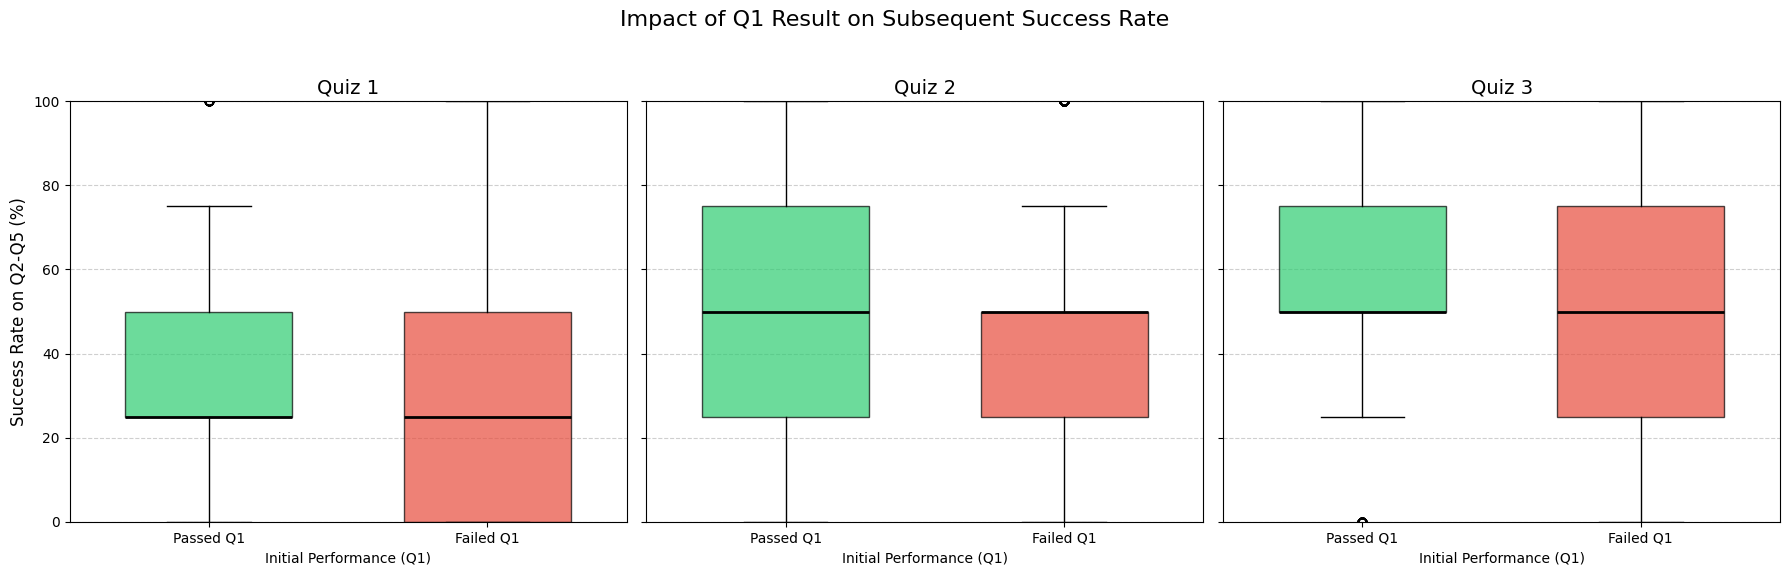

In [45]:
quiz_dfs = [quiz1_data, quiz2_data, quiz3_data]
quiz_names = ["Quiz 1", "Quiz 2", "Quiz 3"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle("Impact of Q1 Result on Subsequent Success Rate", fontsize=16)

for i, df in enumerate(quiz_dfs):
    ax = axes[i]

    # Split by Q1 outcome and use success-rate distribution on Q2-Q5
    passed_rates = df.loc[df["Q1_Status"] == "Passed Q1 (2/2)", "Subsequent_Success_Rate"].dropna()
    failed_rates = df.loc[df["Q1_Status"] == "Failed Q1 (0/2)", "Subsequent_Success_Rate"].dropna()

    data_to_plot = [passed_rates, failed_rates]
    labels = ["Passed Q1", "Failed Q1"]

    box = ax.boxplot(
        data_to_plot,
        tick_labels=labels,
        patch_artist=True,
        widths=0.6,
        medianprops={"color": "black", "linewidth": 2}
    )

    colors = ["#2ecc71", "#e74c3c"]  # Green: passed Q1, Red: failed Q1
    for patch, color in zip(box["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(quiz_names[i], fontsize=14)
    ax.set_xlabel("Initial Performance (Q1)")
    if i == 0:
        ax.set_ylabel("Success Rate on Q2-Q5 (%)", fontsize=12)

    ax.yaxis.grid(True, linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)
    ax.set_ylim(0, 100)

plt.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.show()

The figure compares Q2-Q5 success-rate distributions for students who passed Q1 versus failed Q1.

Key observations:
- **Quiz 1**: Students who failed Q1 show a lower center and more low-end outcomes, indicating weaker subsequent performance.
- **Quiz 2**: The two groups overlap, but students who passed Q1 generally maintain a slightly better success-rate profile.
- **Quiz 3**: Median values are similar, yet the failed-Q1 group has greater spread toward lower results, showing less consistency.

## Overall Conclusion

- Failing Q1 is associated with equal or lower performance on Q2-Q5 in all three quizzes.
- The discouragement effect is strongest in Quiz 1 and weaker in Quiz 2 and Quiz 3.
- This provides **moderate support** for the hypothesis rather than a uniform effect across every quiz.

<div style="text-align: center;"> *  *  * </div>